****Лабораторна робота №3 “Кластеризація”****

Мета роботи: ознайомитися з методами кластеризації (clustering) на прикладі реального набору музичних даних Spotify Tracks Dataset. Навчитись підбирати оптимальну кількість кластерів (k) за допомогою методу ліктя (elbow), виконувати кластеризацію методом K-Means, знижувати розмірність простору ознак за допомогою PCA для візуалізації та аналізувати характеристики утворених кластерів.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("SpotifyFeatures.csv", sep=",")
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [3]:
display(df.head())
print("Розмірність таблиці:", df.shape)
df.info()
display(df.describe())

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


Розмірність таблиці: (232725, 18)
<class 'pandas.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  str    
 1   artist_name       232725 non-null  str    
 2   track_name        232724 non-null  str    
 3   track_id          232725 non-null  str    
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  str    
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  str    
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 1

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


Було виведено перші рядки набору даних, що дозволило ознайомитися зі структурою таблиці та назвами колонок. Також було визначено розмірність таблиці та типи даних кожного стовпця. За допомогою методу describe() отримано основні статистичні характеристики числових ознак, такі як середнє значення, стандартне відхилення, мінімум і максимум. Це дозволяє оцінити розподіл даних перед подальшою обробкою.

In [4]:
from sklearn.preprocessing import StandardScaler

features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms",
    "popularity"
]
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Форма після стандартизації:", X_scaled.shape)

Форма після стандартизації: (232725, 11)


In [5]:
print(X_scaled[:5])

[[-0.89093479  1.28690794  1.29070344 -0.36796995  0.6833763  -0.48981852
   0.66066116  1.38074423  1.5956073  -1.14136792 -2.26100656]
 [ 0.19199369  0.6302493   0.66868254 -0.18308213 -0.34546718 -0.48981852
  -0.32283546  1.38843461  1.82325339 -0.82186742 -2.20603102]
 [ 0.58529607 -1.66995381 -0.7184024  -0.45583209  1.6445698  -0.48981852
  -0.56492694 -0.33421214 -0.5883258  -0.54529771 -2.09607995]
 [-1.69370266 -0.92978944 -0.43481688 -0.43804404  0.94270123 -0.48981852
  -0.58762302 -0.87638445  1.75059694 -0.69529478 -2.26100656]
 [-1.20342161 -1.31315662 -1.93060126 -0.40516312  1.6389323  -0.08356649
  -0.06561327 -0.24961788  0.74143285 -1.28218355 -2.04110441]]


Було виконано стандартизацію числових ознак. Після перетворення всі значення були приведені до одного масштабу з середнім значенням, близьким до нуля, та одиничним стандартним відхиленням. Це забезпечує коректну роботу алгоритму K-Means, який використовує евклідову відстань.

In [6]:
popular_df = df[df["popularity"] >= 85].copy()

print("Розмірність після фільтрації:", popular_df.shape)
popular_df.head()

Розмірність після фільтрації: (417, 18)


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
9026,Dance,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,99,0.0421,0.726,190440,0.554,0.000000,F,0.1060,-5.290,Minor,0.0917,169.999,4/4,0.335
9027,Dance,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,100,0.5780,0.725,178640,0.321,0.000000,C#,0.0884,-10.744,Minor,0.3230,70.142,4/4,0.319
9028,Dance,Halsey,Without Me,5p7ujcrUXASCNwRaWNHR1C,97,0.2970,0.752,201661,0.488,0.000009,F#,0.0936,-7.050,Major,0.0705,136.041,4/4,0.533
9029,Dance,Ariana Grande,needy,1TEL6MlSSVLSdhOSddidlJ,92,0.7800,0.647,171573,0.309,0.000007,G,0.2020,-7.948,Minor,0.0366,87.045,4/4,0.195
9030,Dance,Ariana Grande,NASA,4uTvPEr01pjTbZgl7jcKBD,91,0.4510,0.747,182000,0.458,0.000000,F#,0.2520,-6.891,Major,0.3030,75.029,4/4,0.470


Було виконано фільтрацію даних, залишивши лише треки з популярністю не менше 85. Це дозволяє зменшити кількість точок при візуалізації та зробити графіки більш наочними. При цьому повний набір даних використовується для навчання моделі.

In [7]:
from sklearn.cluster import KMeans

inertias = []
k_values = range(2, 16)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

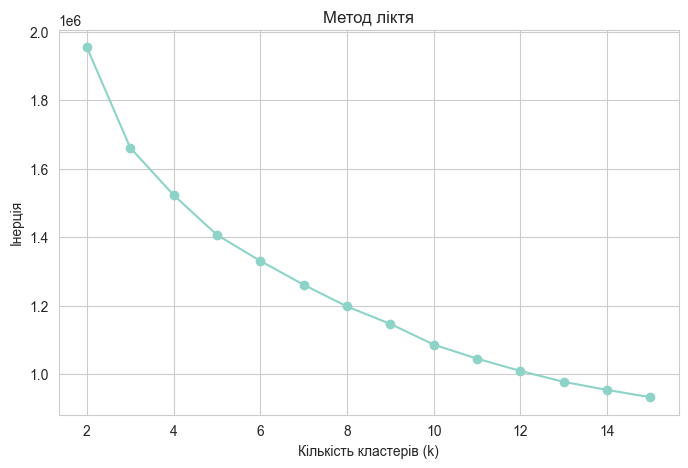

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Кількість кластерів (k)")
plt.ylabel("Інерція")
plt.title("Метод ліктя")
plt.grid(True)
plt.show()

Для визначення оптимальної кількості кластерів було застосовано метод ліктя. Було обчислено значення інерції для різної кількості кластерів у діапазоні від 2 до 15. На основі побудованого графіка залежності інерції від кількості кластерів було визначено точку перегину, яка відповідає оптимальному значенню k. Після цієї точки зменшення інерції стає менш значним, що свідчить про доцільність вибору саме цього значення кількості кластерів.

На графіку методу ліктя спостерігається суттєве зменшення інерції при збільшенні кількості кластерів від 2 до 5. Починаючи з k = 5, подальше зменшення інерції стає менш вираженим, тобто крива починає вирівнюватися. Тому як оптимальне значення кількості кластерів було обрано k = 5.

In [9]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

print("Кількість треків у кожному кластері:")
print(df["cluster"].value_counts().sort_index())

Кількість треків у кожному кластері:
cluster
0    29443
1    60841
2    87225
3    10108
4    45108
Name: count, dtype: int64


Було виконано кластеризацію даних методом K-Means з обраною кількістю кластерів k = 5. Кожному об'єкту було присвоєно мітку кластера, яку додано до DataFrame у вигляді нової колонки cluster. Далі було визначено кількість об'єктів у кожному кластері. Отримані результати показали, що розподіл об'єктів між кластерами є нерівномірним, що свідчить про наявність різних за розміром груп у даних.

In [10]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

df["PC1"] = X_pca_2d[:, 0]
df["PC2"] = X_pca_2d[:, 1]

print("Пояснена дисперсія (2 компоненти):")
print(pca_2d.explained_variance_ratio_)
print("Сумарно:", pca_2d.explained_variance_ratio_.sum())

Пояснена дисперсія (2 компоненти):
[0.3282235  0.15545747]
Сумарно: 0.48368097084666606


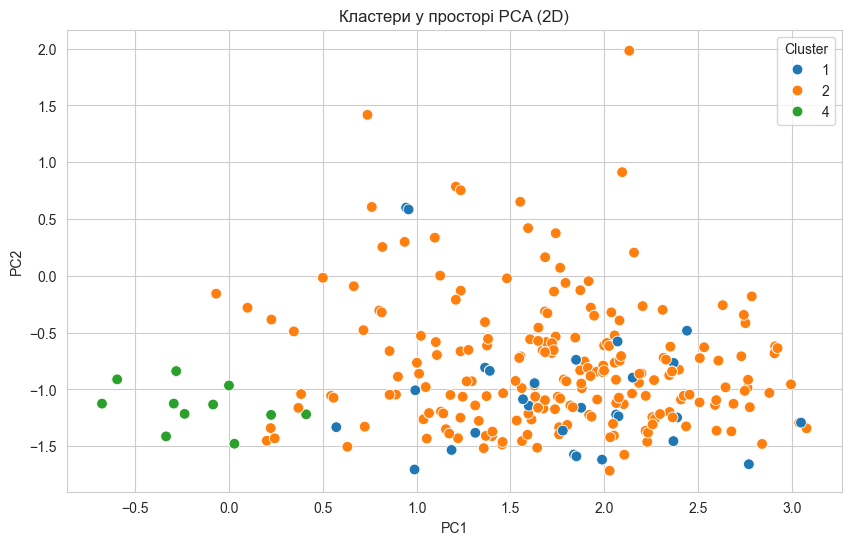

In [11]:
popular_df = df[df["popularity"] >= 85].copy()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=popular_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=60
)

plt.title("Кластери у просторі PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

На 2D-візуалізації у просторі перших двох головних компонент спостерігається, що частина кластерів частково перекривається, що свідчить про схожість деяких об'єктів. Водночас один із кластерів є більш відокремленим, що вказує на наявність групи треків з відмінними характеристиками.

In [12]:
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

df["PC1_3D"] = X_pca_3d[:, 0]
df["PC2_3D"] = X_pca_3d[:, 1]
df["PC3_3D"] = X_pca_3d[:, 2]

print("Пояснена дисперсія (3 компоненти):")
print(pca_3d.explained_variance_ratio_)
print("Сумарно:", pca_3d.explained_variance_ratio_.sum())

Пояснена дисперсія (3 компоненти):
[0.3282235  0.15545747 0.10647707]
Сумарно: 0.5901580393701499


In [13]:
popular_df = df[df["popularity"] >= 85].copy()
import plotly.express as px

popular_df = df[df["popularity"] >= 85].copy()

fig = px.scatter_3d(
    popular_df,
    x="PC1_3D",
    y="PC2_3D",
    z="PC3_3D",
    color=popular_df["cluster"].astype(str),
    title="3D-візуалізація кластерів",
)

fig.show()

У 3D-візуалізації, що враховує третю головну компоненту, кластери розділяються більш чітко. Це свідчить про те, що додаткова компонента дозволяє краще врахувати варіацію даних та зменшити перекриття між кластерами, яке спостерігалось у 2D-просторі.

In [14]:
cluster_means = df.groupby("cluster")[features].mean().round(3)
display(cluster_means)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
cluster,,,,,,,,,,,
0,0.286,0.160,-20.902,0.047,0.856,0.680,0.154,0.148,102.042,263165.983,26.823
1,0.496,0.771,-6.004,0.093,0.104,0.100,0.250,0.451,145.110,244797.228,42.495
2,0.696,0.676,-6.839,0.106,0.174,0.050,0.172,0.604,108.431,224922.274,49.511
3,0.562,0.662,-12.026,0.877,0.793,0.001,0.730,0.414,97.952,243765.746,20.692
4,0.531,0.347,-11.714,0.066,0.689,0.089,0.175,0.381,113.127,221555.217,36.987


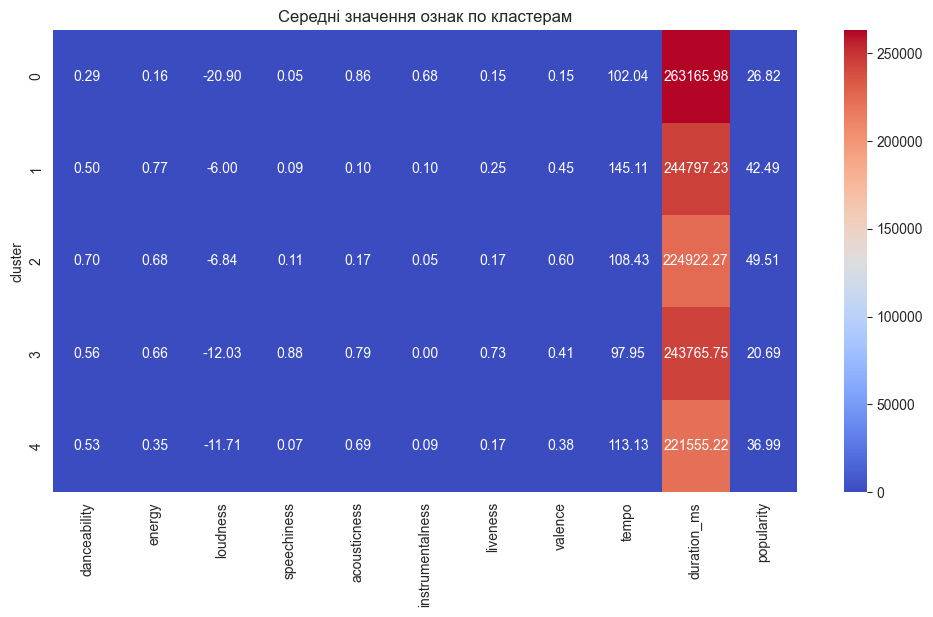

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Середні значення ознак по кластерам")
plt.show()

Було проведено аналіз кластерів на основі середніх значень основних аудіо-ознак. Встановлено, що кожен кластер має характерні особливості.

Кластер 0 характеризується високим рівнем acousticness та низькими значеннями energy і tempo, що відповідає спокійним акустичним композиціям.

Кластер 1 має високі значення energy і tempo та низький acousticness, що свідчить про енергійні швидкі треки.

Кластер 2 відзначається високими значеннями danceability та valence, що відповідає танцювальним і позитивним композиціям.

Кластер 3 характеризується дуже високим значенням speechiness, що свідчить про переважання мовного або вокального контенту.

Кластер 4 має середні значення більшості ознак і представляє треки без яскраво виражених характеристик.

Висновок: у ході виконання лабораторної роботи було досліджено методи кластеризації на прикладі реального набору музичних даних Spotify Tracks Dataset. Було виконано попередню обробку даних, зокрема проаналізовано структуру таблиці та проведено стандартизацію числових ознак, що забезпечило коректну роботу алгоритму кластеризації.

За допомогою методу ліктя було визначено оптимальну кількість кластерів, після чого виконано кластеризацію методом K-Means. Отримані результати показали, що дані природно розбиваються на декілька груп із різними характеристиками. Для візуалізації багатовимірного простору було застосовано метод головних компонент (PCA), що дозволило відобразити структуру кластерів у двовимірному та тривимірному просторі.

Подальший аналіз середніх значень ознак у кожному кластері дозволив інтерпретувати отримані групи. Було встановлено, що кластери відповідають різним типам музичних композицій, таким як енергійні танцювальні треки, спокійні акустичні композиції, вокальні або мовні треки та інші.

Таким чином, у роботі було продемонстровано ефективність застосування методів кластеризації для виявлення прихованої структури даних та групування об'єктів за їх характеристиками.